In [8]:
from collections import Counter
from pathlib import Path

data_dir = Path("../data/cv/raw")

class_counts = Counter()

for class_dir in data_dir.iterdir():
    if class_dir.is_dir():
        class_counts[class_dir.name] = len(list(class_dir.glob("*")))

print(class_counts)

Counter({'dog': 4863, 'spider': 4821, 'chicken': 3098, 'horse': 2623, 'butterfly': 2112, 'cow': 1866, 'squirrel': 1862, 'sheep': 1820, 'cat': 1668, 'elephant': 1446})


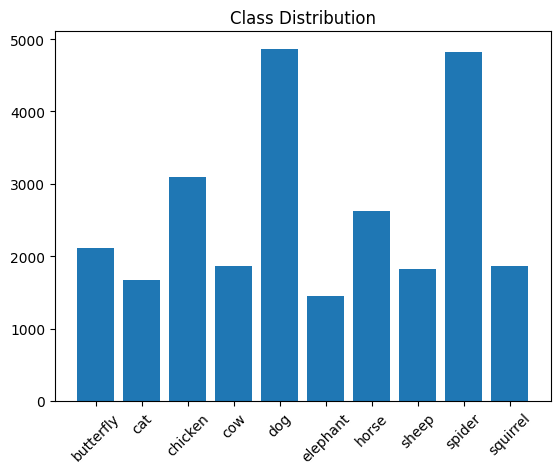

In [9]:
import matplotlib.pyplot as plt

classes = list(class_counts.keys())
counts = list(class_counts.values())

plt.figure()
plt.bar(classes, counts)
plt.xticks(rotation=45)
plt.title("Class Distribution")
plt.show()

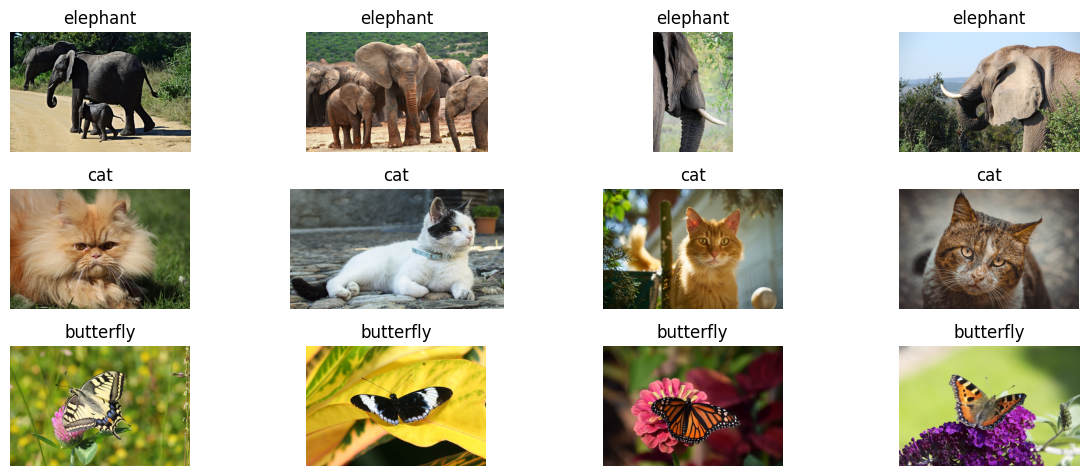

In [10]:
import random
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image

data_dir = Path("../data/cv/raw")

num_classes_to_show = 5
num_images_per_class = 4

class_dirs = [d for d in data_dir.iterdir() if d.is_dir()]
selected_classes = random.sample(class_dirs, min(len(class_dirs), num_classes_to_show))

plt.figure(figsize=(12, 8))

plot_idx = 1

for class_dir in selected_classes:
    images = list(class_dir.glob("*.jpg"))
    sampled_images = random.sample(images, min(len(images), num_images_per_class))

    for img_path in sampled_images:
        try:
            img = Image.open(img_path).convert("RGB")

            plt.subplot(num_classes_to_show, num_images_per_class, plot_idx)
            plt.imshow(img)
            plt.title(class_dir.name)
            plt.axis("off")

            plot_idx += 1
        except:
            continue

plt.tight_layout()
plt.show()

In [12]:
from PIL import Image

broken_images = []
valid_count = 0

for class_dir in data_dir.iterdir():
    if class_dir.is_dir():
        for img_path in class_dir.glob("*"):
            try:
                with Image.open(img_path) as img:
                    img.verify()
                valid_count += 1
            except Exception:
                broken_images.append(img_path)

print("Valid images:", valid_count)
print("Broken images:", len(broken_images))

Valid images: 26179
Broken images: 0


In [13]:
for path in broken_images:
    path.unlink()